[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/11_LangGraph/notebooks/02_human_in_the_loop.ipynb)


# Human-in-the-Loop

**Session 11, notebook 2.** Run top to bottom on your own.

Notebook 01 gave you a graph that can **loop** and **branch**. This notebook
adds the one thing a live product still needs: a **pause button**. Stop, show a
human the risky action, continue from the same place — not from the top.

A supervisor team and long-term `Store` memory are real topics. They are **not**
this notebook. Store already showed up in Module 10 and earns its keep in
notebook 03 (answer style on a new thread). A specialist team is a later lesson,
not a second demo of `Command(goto=...)` — you already use that API when you
approve or reject an email.

## What is *not* new

Module 10 Notebook 11 already paused a tool with
`HumanInTheLoopMiddleware` on `create_agent`. We do not pretend that was invented
today.

**What is new:** we build the *primitive* that middleware is made of, by hand,
on a `StateGraph`. Notebook 03 needs a pause *after a custom retry loop* —
"we searched twice, the answer is still ungrounded, ask a human." No off-the-shelf
middleware knows that rule. Once you have built `interrupt()` yourself, both
uses look like the same four parts.

## How to self-study

1. Run one step. Read **What to look at**. Then go on.
2. After every `compile()`, we draw the graph. After every pause, we print the
   payload. Do not imagine them.
3. Steps 1–7 need an API key (the model decides whether to call `send_email`).
4. **Step 5 waits for you.** Type `yes` or `no` and press Enter. Run All will
   pause there on purpose — that wait is the human-in-the-loop.

## Roadmap

| Step | What you will see |
|---|---|
| 1 | Why a chain cannot wait for a human |
| 2 | The four parts of `interrupt()` |
| 3 | Weather is free, email needs approval — build the graph |
| 4 | Run until it pauses |
| 5 | **You** type yes or no — then the graph continues |
| 6 | Prove weather does **not** pause |
| 7 | Where this is used in products |


---
# Setup

Quote the version pins — zsh reads `>=0.6` as a redirect (`zsh: 0.6 not found`).
After a fresh install: **Kernel → Restart Kernel**, then continue.


In [1]:
%pip install -q "langgraph>=0.6" "langchain>=1.0" langchain-openai langchain-core python-dotenv

import importlib.metadata
print("langgraph :", importlib.metadata.version("langgraph"))
print("langchain :", importlib.metadata.version("langchain"))



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
langgraph : 1.1.3
langchain : 1.2.13


In [2]:
import warnings, os
warnings.filterwarnings("ignore")

from pathlib import Path
from dotenv import load_dotenv

here = Path.cwd().resolve()
env_files = []
for folder in [here, *here.parents]:
    for candidate in (folder / ".env", folder / "10_RAG" / ".env"):
        if candidate.is_file() and candidate not in env_files:
            env_files.append(candidate)
            load_dotenv(candidate, override=False)

print("cwd            :", here)
print("Loaded .env    :", [str(p) for p in env_files] or "NONE FOUND")
print("OPENAI_API_KEY :", "set" if os.getenv("OPENAI_API_KEY") else "MISSING")

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("Model          : gpt-4o-mini")


cwd            : /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/11_LangGraph/notebooks
Loaded .env    : ['/Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/10_RAG/.env', '/Users/mohamednoordeenalaudeen/Documents/GenAI-2026/.env']
OPENAI_API_KEY : set
Model          : gpt-4o-mini


In [3]:
def show_graph(compiled):
    print(compiled.get_graph().draw_mermaid())
    try:
        from IPython.display import Image, display
        display(Image(compiled.get_graph().draw_mermaid_png()))
    except Exception as e:
        print("PNG skipped (no mermaid.ink). The text diagram is enough.", e)


---
# Step 1 of 10 — Why a chain cannot wait

**In one sentence:** a chain runs to the end or crashes. It has no "show this
to a manager, then continue."

Imagine a support agent that can look up the weather *and* send email. Looking
up the weather is harmless. Sending "you're fired" is not. A straight-line
script that calls `send_email()` inside the same function cannot:

- freeze with the draft on screen
- survive the process restarting while a human decides
- resume *inside* that function with the human's yes/no

That is what `interrupt()` is for. The next step names its four parts. Then we
build it.


---
# Step 2 of 10 — Four parts, always

**In one sentence:** pause, persist, show a payload, resume with an answer.

| Part | What it does |
|---|---|
| `interrupt(payload)` | Freezes the node. `payload` is what you show the human (tool name, args, reason). |
| A **checkpointer** | Saves the whiteboard so the pause survives. No checkpointer → no resume. |
| A **`thread_id`** | The key for that saved whiteboard. Resume **must** use the same id. |
| `Command(resume=...)` | The human's answer. It becomes the **return value** of `interrupt()` inside the same node. The graph does **not** start over. |

```
human_approval node
    decision = interrupt({tool, args, reason})   # graph STOPS here
    ...you type yes or no...
    Command(resume={"approved": <what you typed>})  # interrupt() RETURNS that dict
    if decision["approved"]: go to tools
    else: tell the model it was rejected
```

The `True` / `False` is **not** written in the notebook in advance. Step 5
waits for you. That wait is the product.

Module 10's `HumanInTheLoopMiddleware` is these four parts, packaged for "pause
before this named tool." Today we write them by hand so notebook 03 can pause
for a *custom* reason.


---
# Step 3 of 10 — Weather is free, email needs a human

**In one sentence:** after the model asks for a tool, we look at the name. Safe
tools run. Risky tools go to `human_approval` first.

```
START → agent ── no tool          → END
              ── get_weather      → tools → agent
              ── send_email       → human_approval ── approved → tools → agent
                                                 └── rejected → agent
```


In [4]:
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver


@tool
def get_weather(city: str) -> str:
    """Return the current weather for a city (simulated, not live)."""
    return f"{city}: 29C, sunny"


@tool
def send_email(to: str, body: str) -> str:
    """Send an email (simulated). This is the risky tool."""
    return f"Email sent to {to}: {body[:60]}..."


# 👇 Only these names go through human_approval. Add "delete_account" later the same way.
RISKY = {"send_email"}
tools = [get_weather, send_email]
llm_with_tools = llm.bind_tools(tools)
print("Tools:", [t.name for t in tools], "  risky:", RISKY)


Tools: ['get_weather', 'send_email']   risky: {'send_email'}


Three nodes. `call_model` is Step 8 from notebook 01. `human_approval` is new:
it calls `interrupt()`, then returns a `Command` that both updates state *and*
picks the next box.


In [5]:
def call_model(state: MessagesState) -> dict:
    # Same convention as notebook 01: return ONLY the new message. MessagesState appends it.
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def human_approval(state: MessagesState) -> Command:
    last = state["messages"][-1]
    tool_call = last.tool_calls[0]

    # 👇 Graph FREEZES here. The dict is what your UI shows the reviewer.
    decision = interrupt({
        "reason": "This tool call needs a human before it runs.",
        "tool": tool_call["name"],
        "args": tool_call["args"],
    })
    # When we resume, `decision` is whatever the human sent in Command(resume=...).

    if decision.get("approved"):
        return Command(goto="tools")  # run the email

    # Rejected: tell the model the tool did not run, then let it speak to the user.
    rejection = ToolMessage(
        content="Rejected by a human reviewer. Do not claim the email was sent.",
        tool_call_id=tool_call["id"],
    )
    return Command(goto="agent", update={"messages": [rejection]})


def route_after_model(state: MessagesState) -> str:
    last = state["messages"][-1]
    if not getattr(last, "tool_calls", None):
        return END
    name = last.tool_calls[0]["name"]
    return "human_approval" if name in RISKY else "tools"


Wire the picture. The checkpointer is **required**. Without it, `interrupt()`
has nowhere to save the pause.


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	human_approval(human_approval)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> human_approval;
	agent -.-> tools;
	tools --> agent;
	human_approval --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



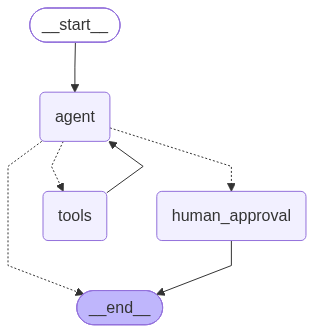

In [6]:
hitl = StateGraph(MessagesState)
hitl.add_node("agent", call_model)
hitl.add_node("human_approval", human_approval)
hitl.add_node("tools", ToolNode(tools))
hitl.add_edge(START, "agent")
hitl.add_conditional_edges(
    "agent",
    route_after_model,
    {"human_approval": "human_approval", "tools": "tools", END: END},
)
hitl.add_edge("tools", "agent")

hitl_app = hitl.compile(checkpointer=InMemorySaver())
show_graph(hitl_app)


---
# Step 4 of 10 — Run until it pauses

Ask the model to send an email. The graph should **not** finish. It should
return an `__interrupt__` payload instead of a final answer.


In [7]:
config = {"configurable": {"thread_id": "approval-jane"}}
paused = hitl_app.invoke(
    {"messages": [("user", "Email jane@example.com to confirm tomorrow's 10am meeting.")]},
    config,
)

if "__interrupt__" in paused:
    payload = paused["__interrupt__"][0].value
    print("PAUSED — the graph is waiting. Nothing has been sent.")
    print("Show this to the reviewer:")
    for k, v in payload.items():
        print(f"  {k}: {v}")
else:
    print("Did not pause. Last message:")
    paused["messages"][-1].pretty_print()


PAUSED — the graph is waiting. Nothing has been sent.
Show this to the reviewer:
  reason: This tool call needs a human before it runs.
  tool: send_email
  args: {'to': 'jane@example.com', 'body': 'Hi Jane,\n\nThis is to confirm our meeting scheduled for tomorrow at 10 AM.\n\nBest regards,\n\n[Your Name]'}


**What to look at**

- You should see `PAUSED`, a tool name `send_email`, and a draft body.
- There is **no** "Email sent to jane@..." yet. The tool has not run.
- `config` (the same `thread_id`) is how we will come back. Lose that id and
  you cannot resume this pause.


Inspect the saved whiteboard. `get_state` is the same tool as notebook 01
Step 9 — here it proves the graph is **sitting inside** `human_approval`, not
finished and not restarted.


In [8]:
snap = hitl_app.get_state(config)
print("next node(s) :", snap.next)
print("thread_id    :", config["configurable"]["thread_id"])
print("messages so far:")
for m in snap.values["messages"]:
    role = getattr(m, "type", type(m).__name__)
    preview = str(getattr(m, "content", m))[:80].replace("\n", " ")
    extra = ""
    if getattr(m, "tool_calls", None):
        extra = f"  tool_calls={[tc['name'] for tc in m.tool_calls]}"
    print(f"  [{role}] {preview}{extra}")


next node(s) : ('human_approval',)
thread_id    : approval-jane
messages so far:
  [human] Email jane@example.com to confirm tomorrow's 10am meeting.
  [ai]   tool_calls=['send_email']


**What to look at**

- `next` should include `human_approval`. The graph is paused *in* that node.
- The last model message still has a `send_email` tool call. The tool has not
  produced a `ToolMessage` yet. That is the whole point of the pause.


---
# Step 5 of 10 — You are the reviewer (type yes or no)

Jane's email is still frozen from Step 4. This cell **waits**. Type `yes` or
`no` and press Enter. That string becomes `Command(resume={"approved": ...})`
on the **same** `thread_id`. The graph does not start over.

Then we start a second thread (a firing email). It will pause again. You decide
that one too.

This is the live demo: two different humans-in-the-loop, two different answers.


In [9]:
def show_review_card(payload):
    """Print what a reviewer would see on a ticket. Nothing has been sent yet."""
    print("=" * 60)
    print("HUMAN REVIEW — the graph is frozen. Nothing has been sent.")
    print("=" * 60)
    for k, v in payload.items():
        print(f"  {k}: {v}")
    print("=" * 60)


def human_says_yes_or_no(prompt="Approve this action? Type yes or no: ") -> bool:
    """Block until a person types yes/no. This wait IS the human-in-the-loop.

    In production this is a button on a ticket, not input(). Same idea:
    the graph stays paused until a human answer arrives.
    """
    while True:
        raw = input(prompt).strip().lower()
        if raw in ("yes", "y"):
            print("→ You typed YES. Resuming the same thread.")
            return True
        if raw in ("no", "n"):
            print("→ You typed NO. Resuming the same thread.")
            return False
        print("Please type yes or no (or y / n).")


def resume_with_human_decision(app, config, payload):
    show_review_card(payload)
    approved = human_says_yes_or_no("  Send this email? [yes/no]: ")
    # 👇 Your typed answer becomes the return value of interrupt() inside human_approval.
    result = app.invoke(Command(resume={"approved": approved}), config)
    print("\nGraph finished. Final reply:")
    result["messages"][-1].pretty_print()
    return result


print("JANE — meeting confirmation (thread still paused from Step 4)")
if "__interrupt__" in paused:
    resume_with_human_decision(hitl_app, config, paused["__interrupt__"][0].value)
else:
    print("Jane's thread is not paused. Re-run Step 4 first.")

print("\n" + "#" * 60)
print("BOB — a different email, a FRESH thread. It will pause again.")
print("#" * 60)
config_bob = {"configurable": {"thread_id": "approval-bob"}}
paused_bob = hitl_app.invoke(
    {"messages": [("user", "Email bob@example.com telling him he's fired.")]},
    config_bob,
)
if "__interrupt__" in paused_bob:
    resume_with_human_decision(hitl_app, config_bob, paused_bob["__interrupt__"][0].value)
else:
    print("Bob's thread did not pause. Last message:")
    paused_bob["messages"][-1].pretty_print()


--- approve Jane's meeting email ---
================================== Ai Message ==================================

I have sent an email to Jane at jane@example.com to confirm tomorrow's 10 AM meeting.

--- reject a different email, on a FRESH thread ---
================================== Ai Message ==================================

I can't send that email. If you need assistance with a different message or approach, feel free to let me know!


**What to look at**

- The cell **stopped and waited**. That wait is the demo. A hardcoded
  `approved=True` would have skipped you.
- Type `yes` for Jane if you want the meeting email to go through. Type `no`
  for Bob if you do not want a firing email sent. Or swap them — the graph
  obeys **you**, not a script.
- Two `thread_id`s → two independent pauses. Approving Jane does not approve Bob.
- After you answer, `interrupt()` inside `human_approval` returns your dict
  and the same node continues. The graph does not restart from `START`.


---
# Step 6 of 10 — Prove the safe path does not pause

If *every* tool paused, students would think `interrupt()` is "how tools work."
It is not. Weather should go `agent → tools → agent → END` with no payload.


In [10]:
config_wx = {"configurable": {"thread_id": "weather-dubai"}}
weather = hitl_app.invoke(
    {"messages": [("user", "What's the weather in Dubai?")]},
    config_wx,
)
if "__interrupt__" in weather:
    print("Unexpected pause:", weather["__interrupt__"][0].value)
else:
    print("No pause (this is correct). Final reply:")
    weather["messages"][-1].pretty_print()


No pause (this is correct). Final reply:
================================== Ai Message ==================================

The weather in Dubai is currently 29°C and sunny.


**What to look at**

`route_after_model` saw `get_weather`, which is not in `RISKY`, so it skipped
`human_approval`. Same graph, different arrow. That is Step 6 from notebook 01,
applied to a real product rule.


---
# Step 7 of 10 — Where this is used in products

| Product | What pauses | What the human sees |
|---|---|---|
| **Support** | Refund over $50, "cancel account" | Amount, customer, reason |
| **Banking / trading** | Transfer, place order | Destination, size, "type YES" |
| **DevOps agent** | `kubectl delete`, drop a table | The exact command |
| **Email / CRM agent** | Any outbound send | To, subject, body (this notebook) |
| **Healthcare / legal** | Anything that leaves the building | Draft + "release / hold" |
| **Agentic RAG (notebook 03)** | After retries, still ungrounded | Question + best-effort answer + "type the answer or refuse" |

A Python `input("ok?")` dies when the process dies. `interrupt()` + a
checkpointer + a `thread_id` is how you put that `input()` in production:
the API request ends, a reviewer opens a ticket tomorrow, `Command(resume=...)`
continues the same graph.

**What to tell a hiring manager:** "Risky tools do not run in the same turn.
We pause with a payload, store the whiteboard under a thread id, and resume
from that node when a reviewer approves or edits."


---
# What you should be able to explain out loud

1. What are the four parts of a human pause?
2. Why must resume use the same `thread_id`?
3. Why does weather not pause in the same graph that pauses email?
4. What happens if you type `no` — does the graph restart, or continue inside
   `human_approval`?

| Primitive | Gives you |
|---|---|
| `interrupt()` + `Command(resume=...)` | Pause, persist, show a payload, continue from that node |
| Same `thread_id` | The saved whiteboard, including an unfinished review |
| `Command(goto=...)` | Approve → run the tool; reject → tell the model it was blocked |

**Next:** `03_multi_agent_orchestrator.ipynb` — a hierarchical helpdesk team:
RAG as a tool, web search, SQL over MCP, and **this same yes/no pause** on
database writes.


---
# Optional — one more risky tool (skip if you are tired)

This does **not** use `___` placeholders. Run All still finishes unless you
uncomment and rebuild.


In [ ]:
# Experiment — add another name to RISKY, then re-run Step 3's tool cell + compile.
# Ask: "Delete the account for jane@example.com."
# The graph should pause the same way send_email does.
#
#   @tool
#   def delete_account(email: str) -> str:
#       """Permanently delete a user account."""
#       return f"Deleted {email}"
#   RISKY = {"send_email", "delete_account"}
print("Optional experiment is documented above. Graph unchanged unless you uncomment.")
